# 03 — Genetic Algorithm (GA) Feature Selection

**Goal:** use GA to search for the feature subset that maximizes classification
performance while minimizing the number of features used. GA maintains a population of candidate solutions and evolves it via selection, crossover, and mutation — mimicking natural evolution.

This notebook follows the exact same pipeline as every other optimizer notebook in
this project (GA / PSO / GWO / WOA) — only the optimizer differs — so results are
directly comparable in `07_Comparison.ipynb`.

**Pipeline:**

```
Initialize population (random binary-ish vectors)
        |
        v
  Evaluate fitness (via utils.fitness.fitness)
        |
        v
     Selection   (roulette-wheel / tournament)
        |
        v
     Crossover   (single/multi-point, prob. pc)
        |
        v
     Mutation    (bit-flip style, prob. pm)
        |
        v
   Repeat for `epoch` generations
        |
        v
  Return best feature subset
```


In [1]:
import sys
sys.path.append("..")

import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocessing import load_processed_data
from utils.metrics import evaluate_subset
from utils.fitness import make_fitness_fn

In [8]:
# ----------------------------
# Binary Genetic Algorithm
# ----------------------------

def initialize_population(pop_size, n_features):
    return np.random.randint(0, 2, (pop_size, n_features))


def tournament_selection(population, fitness, k=3):
    idx = np.random.choice(len(population), k, replace=False)

    tournament_fitness = fitness[idx]

    winner = idx[np.argmin(tournament_fitness)]

    return population[winner].copy()


def crossover(parent1, parent2, pc=0.9):
    if random.random() > pc:
        return parent1.copy(), parent2.copy()

    point = random.randint(1, len(parent1)-2)

    child1 = np.concatenate((parent1[:point], parent2[point:]))
    child2 = np.concatenate((parent2[:point], parent1[point:]))

    return child1, child2


def mutation(individual, pm=0.05):
    child = individual.copy()

    for i in range(len(child)):
        if random.random() < pm:
            child[i] = 1 - child[i]

    if np.sum(child) == 0:
        child[random.randint(0, len(child)-1)] = 1

    return child


def run_ga(obj_func,
           n_features,
           pop_size=30,
           generations=50,
           pc=0.9,
           pm=0.05):

    population = initialize_population(pop_size, n_features)

    history = []

    best_solution = None
    best_fitness = np.inf

    for g in range(generations):

        fitness = np.array([obj_func(ind) for ind in population])

        idx = np.argmin(fitness)

        if fitness[idx] < best_fitness:
            best_fitness = fitness[idx]
            best_solution = population[idx].copy()

        history.append(best_fitness)

        new_population = []

        while len(new_population) < pop_size:

            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)

            c1, c2 = crossover(p1, p2, pc)

            c1 = mutation(c1, pm)
            c2 = mutation(c2, pm)

            new_population.extend([c1, c2])

        population = np.array(new_population[:pop_size])

    return best_solution, best_fitness, history

## 1. Load processed data (from notebook 01)

In [4]:
X_train, X_test, y_train, y_test, feature_names = load_processed_data("../datasets")
n_features = X_train.shape[1]
print("Number of features:", n_features)

Number of features: 30


## 2. Define the fitness function

`utils.fitness.fitness` is shared across ALL optimizer notebooks. It combines
classification error with a small penalty on the number of selected features.

In [5]:
fitness_fn = make_fitness_fn(
    X_train, X_test, y_train, y_test,
    classifier="svm",   # keep consistent with the baseline notebook
    alpha=0.99,
)

# mealpy expects fit_func(solution) -> float (to minimize)
def obj_func(solution):
    return fitness_fn(solution)

## 3. Configure and run GA

Solutions are continuous vectors in [0, 1]^n_features; each dimension is
binarized (`>0.5` -> feature selected) inside the fitness function.

In [9]:
# GA parameters
GENERATIONS = 50
POP_SIZE = 30
CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.05

start_time = time.time()

best_position, best_fitness, convergence_curve = run_ga(
    obj_func=fitness_fn,
    n_features=n_features,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    pc=CROSSOVER_RATE,
    pm=MUTATION_RATE
)

runtime = time.time() - start_time

print(f"Best fitness: {best_fitness:.6f}")
print(f"Runtime: {runtime:.2f} seconds")

Best fitness: 0.003000
Runtime: 49.33 seconds


## 4. Extract convergence curve

Saved for the comparison plots in `07_Comparison.ipynb`.

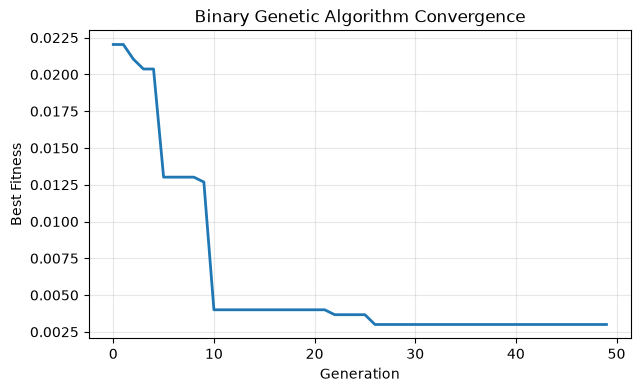

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(convergence_curve, linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Binary Genetic Algorithm Convergence")

plt.grid(alpha=0.3)
plt.show()

## 5. Evaluate the best feature subset

Using the exact same `evaluate_subset()` function as the baseline notebook.

In [11]:
best_mask = best_position.astype(int)

selected_features = [
    f for f, m in zip(feature_names, best_mask)
    if m == 1
]

print(f"GA selected {best_mask.sum()} / {n_features} features:")
print(selected_features)

results = evaluate_subset(
    best_mask,
    X_train,
    X_test,
    y_train,
    y_test,
    classifier="svm"
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "n_features"]:
    print(f"{metric}: {results[metric]}")

GA selected 9 / 30 features:
['mean concavity', 'mean fractal dimension', 'perimeter error', 'compactness error', 'fractal dimension error', 'worst area', 'worst smoothness', 'worst concavity', 'worst fractal dimension']
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
roc_auc: 1.0
n_features: 9


## 6. Save results

Saved to `../results/ga_results.csv` and
`../results/ga_convergence.npy` for `07_Comparison.ipynb`.

In [12]:
import os
os.makedirs("../results", exist_ok=True)

results_df = pd.DataFrame([{
    "Algorithm": "GA",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1": results["f1"],
    "ROC_AUC": results["roc_auc"],
    "Features": results["n_features"],
    "Runtime": runtime,
}])

results_df.to_csv("../results/ga_results.csv", index=False)
np.save("../results/ga_convergence.npy", np.array(convergence_curve))
np.save("../results/ga_mask.npy", best_mask)

results_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,GA,1.0,1.0,1.0,1.0,1.0,9,49.331119


## Next step

Run the remaining optimizer notebooks (any not yet run), then open
`07_Comparison.ipynb` to compare GA against the baseline and the other
metaheuristics side by side.